## Data Creation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from models.feedforward_neural_network import FeedForwardNeuralNetwork
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


### Simple Linear Data

$y = 1 + 2x + N(0, 0.5)$

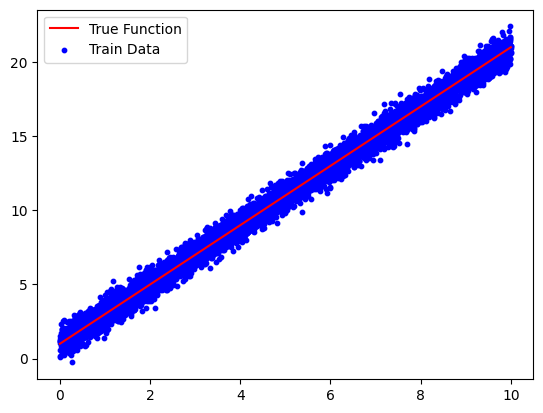

In [2]:
X_lin = np.arange(0, 10, 0.001).reshape(-1, 1)
y_lin = 2*X_lin + 1 + np.random.normal(0, 0.5, X_lin.shape)

X_lin_norm = X_lin
y_lin_norm = y_lin

X_train_lin_norm, X_test_lin_norm, y_train_lin_norm, y_test_lin_norm = train_test_split(X_lin_norm, y_lin_norm, test_size=0.2, random_state=42)

plt.plot(X_lin_norm, 2*X_lin + 1, color = "red", label='True Function')
plt.scatter(X_train_lin_norm, y_train_lin_norm, color='blue', label='Train Data', s=10)
plt.legend()

### Quadratic Data

$y = 1 + 2x_1*x_2 + N(0, 0.5)$

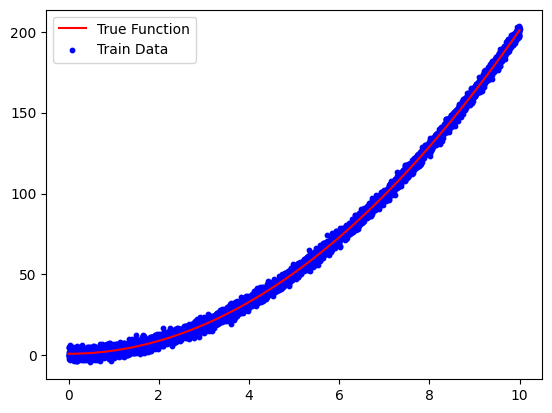

In [3]:
X_quad_1 = np.arange(0, 10, 0.001).reshape(-1, 1)
y_quad = 2*X_quad_1*X_quad_1 + 1 + np.random.normal(0, 2, X_quad_1.shape)

X_quad_1_norm = X_quad_1
y_quad_norm = y_quad

X_train_quad_norm, X_test_quad_norm, y_train_quad_norm, y_test_quad_norm = train_test_split(X_quad_1_norm, y_quad_norm, test_size=0.2, random_state=42)

plt.plot(X_quad_1_norm, 2*X_quad_1*X_quad_1 + 1, color = "red", label='True Function')
plt.scatter(X_train_quad_norm, y_train_quad_norm, color='blue', label='Train Data', s=10)
plt.legend()

In [4]:
FFNN_lin_our = FeedForwardNeuralNetwork([10, 5], epochs=2000, learning_rate=0.001, patience=100, regression=True, verbose=True, auto_save=False).fit(X_train_lin_norm, y_train_lin_norm)
y_pred_lin_our = FFNN_lin_our.predict(X_test_lin_norm)
FFNN_quad_our = FeedForwardNeuralNetwork([5, 10, 15, 15, 10, 5], epochs=2000, learning_rate=0.001, patience=100, regularization_setting=(2, 0.01), regression=True, verbose=True, auto_save=False).fit(X_train_quad_norm, y_train_quad_norm)
y_pred_quad_our = FFNN_quad_our.predict(X_test_quad_norm)

FFNN_lin_skl = MLPRegressor(hidden_layer_sizes=(10, 5), max_iter=2000, learning_rate_init=0.001).fit(X_train_lin_norm, y_train_lin_norm)
y_pred_lin_skl = FFNN_lin_skl.predict(X_test_lin_norm)
FFNN_quad_skl = MLPRegressor(hidden_layer_sizes=(5, 10, 15, 15, 10, 5), max_iter=2000, learning_rate_init=0.001).fit(X_train_quad_norm, y_train_quad_norm)
y_pred_quad_skl = FFNN_quad_skl.predict(X_test_quad_norm)

2000/2000 epochs, Validation loss: 0.249469, Training loss 0.246058. Est. time remaining:         00s
Training stopped at epoch 2000 with best validation loss 0.249469 and best training loss 0.246058 from epoch 1999.
2000/2000 epochs, Validation loss: 4.200488, Training loss 4.041369. Est. time remaining:         00ss7ss
Training stopped at epoch 2000 with best validation loss 4.190490 and best training loss 4.041152 from epoch 1998.


/home/sakul/UNI/3rd Semester/Machine Learning/ITU-MachineLearning-FinalProject-Couriers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sakul/UNI/3rd Semester/Machine Learning/ITU-MachineLearning-FinalProject-Couriers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


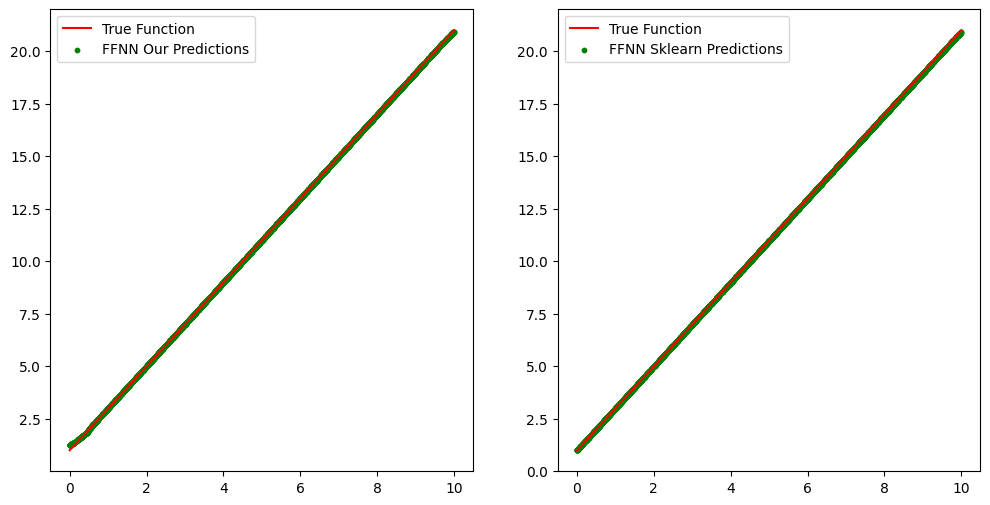

In [5]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(X_lin_norm, (2*X_lin + 1), color = "red", label='True Function')
plt.scatter(X_test_lin_norm, y_pred_lin_our, color='green', label='FFNN Our Predictions', s=10)
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(X_lin_norm, (2*X_lin + 1), color = "red", label='True Function')
plt.scatter(X_test_lin_norm, y_pred_lin_skl, color='green', label='FFNN Sklearn Predictions', s=10)
plt.legend()

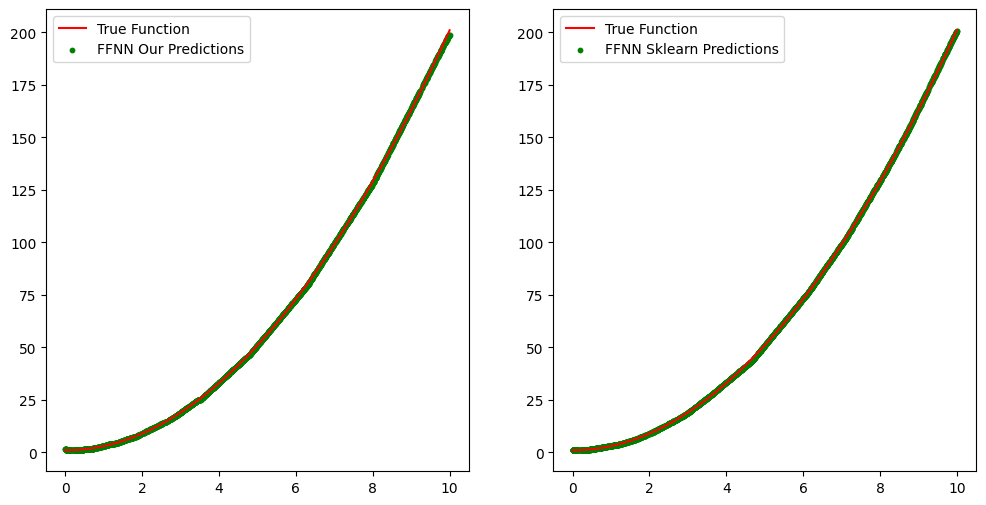

In [6]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(X_quad_1_norm, (2*X_quad_1*X_quad_1 + 1), color = "red", label='True Function')
plt.scatter(X_test_quad_norm, y_pred_quad_our, color='green', label='FFNN Our Predictions', s=10)
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(X_quad_1_norm, (2*X_quad_1*X_quad_1 + 1), color = "red", label='True Function')
plt.scatter(X_test_quad_norm, y_pred_quad_skl, color='green', label='FFNN Sklearn Predictions', s=10)
plt.legend()